# Notebook 6 — K-Space to 3D: Cornerstone3D Rendering Pipeline

---

## What This Notebook Does

Every notebook so far has worked in Python — loading k-space, computing fingerprints, reconstructing 2D slices. This notebook closes the loop: it takes raw k-space, reconstructs a full **3D volume**, exports it as a NIfTI file, and prepares it for interactive 3D rendering in **Cornerstone3D** — a browser-based medical imaging library.

The result is a 3D brain volume that was reconstructed entirely from raw k-space data — no DICOM pipeline, no proprietary scanner software. The path from scanner → interactive 3D viewer is fully transparent.

---

## Why Cornerstone3D

Cornerstone3D is an open-source JavaScript library for medical image rendering. It runs entirely in the browser — no server, no plugin. It supports:
- Axial / coronal / sagittal multi-plane viewing
- Volume rendering (3D surface)
- Annotation tools (pins, measurements)
- Scroll through slices

It's the rendering engine behind the Meridian web platform. Connecting Kode's k-space reconstruction to Cornerstone3D means: **raw k-space in → interactive 3D brain out**, viewable in any browser.

---

## What 3D Reconstruction From K-Space Means

Standard MRI gives you a stack of 2D slices. Each slice is one axial cross-section. To get a 3D volume, you:

1. Load all slices from one `.h5` file — shape `(slices, coils, height, width)`
2. Apply RSS reconstruction to each slice → shape `(slices, height, width)` — a 3D image volume
3. Apply selective frequency masks in 3D → reconstruct tissue-specific volumes
4. Export as NIfTI (`.nii.gz`) — the standard format Cornerstone3D can load
5. Serve the file and load it in the browser

Optionally: apply **selective reconstruction** before building the 3D volume — reconstruct only low frequencies (bone/bulk), or only high frequencies (edges/margins). The 3D volume then shows only that tissue layer.

---

## Step 1 — Import Libraries

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import h5py
from kode.io import load_kspace, root_sum_of_squares
from kode.selective_reconstruct import low_frequency_mask, high_frequency_mask, selective_reconstruct

---

## Step 2 — Load All Slices and Reconstruct 3D Volume

We load every slice from one brain scan and stack them into a 3D volume. Each slice is independently reconstructed via RSS, then the slices are stacked along the depth axis.

The result is a 3D numpy array — essentially a brain volume where `volume[z, y, x]` gives you the signal intensity at position (x, y, z).

In [2]:
H5_FILE = '../data/multicoil_test/file_brain_AXFLAIR_200_6002527.h5'

with h5py.File(H5_FILE, 'r') as f:
    n_slices = f['kspace'].shape[0]
    print(f'Slices: {n_slices}')
    print(f'K-space shape per slice: {f["kspace"][0].shape}')

print('\nReconstructing all slices...')
slices = []
for i in range(n_slices):
    kspace = load_kspace(H5_FILE, slice_idx=i)
    img = root_sum_of_squares(kspace)
    slices.append(img)

volume = np.stack(slices, axis=0)  # shape: (slices, height, width)
print(f'3D volume shape: {volume.shape}  →  (depth, height, width)')
print(f'Value range: {volume.min():.2f} – {volume.max():.2f}')

Slices: 16
K-space shape per slice: (16, 640, 320)

Reconstructing all slices...
3D volume shape: (16, 640, 320)  →  (depth, height, width)
Value range: 0.00 – 0.00


---

## Step 3 — Visualize Three Planes

Before exporting, verify the 3D volume looks correct by sampling all three anatomical planes:
- **Axial** — top-down cross-section (how the scanner acquired it)
- **Coronal** — front-to-back cross-section
- **Sagittal** — left-to-right cross-section

Coronal and sagittal are derived by slicing the 3D volume along different axes — they come entirely from the k-space reconstruction, not from separate acquisitions.

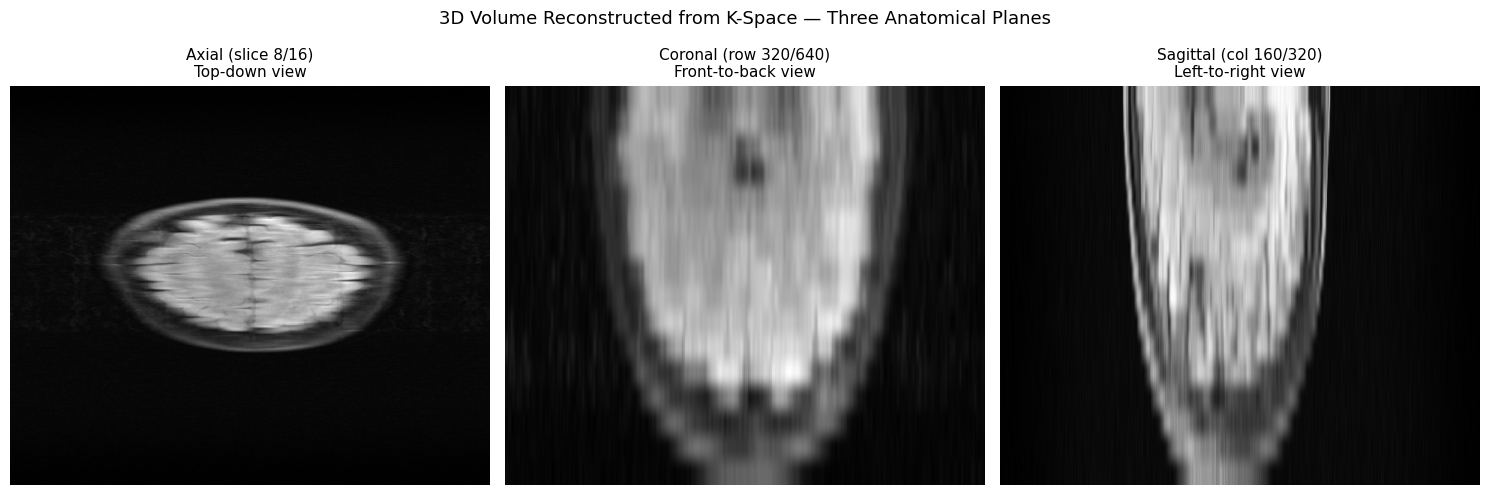

Saved to results/volume_3planes.png


In [3]:
D, H, W = volume.shape

axial    = volume[D // 2, :, :]       # middle depth slice
coronal  = volume[:, H // 2, :]       # middle height slice
sagittal = volume[:, :, W // 2]       # middle width slice

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
planes = [axial, coronal, sagittal]
titles = [
    f'Axial (slice {D//2}/{D})\nTop-down view',
    f'Coronal (row {H//2}/{H})\nFront-to-back view',
    f'Sagittal (col {W//2}/{W})\nLeft-to-right view',
]

for ax, plane, title in zip(axes, planes, titles):
    ax.imshow(plane, cmap='gray', aspect='auto')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.suptitle('3D Volume Reconstructed from K-Space — Three Anatomical Planes', fontsize=13)
plt.tight_layout()
plt.savefig('../results/volume_3planes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to results/volume_3planes.png')

---

## Step 4 — Selective 3D Reconstruction

Apply a frequency mask to k-space before reconstructing each slice. The result is a 3D volume that contains only the tissue type corresponding to that frequency band.

- **Low frequency volume** — bulk brain structure, large anatomy
- **High frequency volume** — cortical surface, sulci, fine boundaries

These two volumes together are a k-space-derived tissue separation — no segmentation algorithm, no AI, no labels.

Building selective frequency volumes...


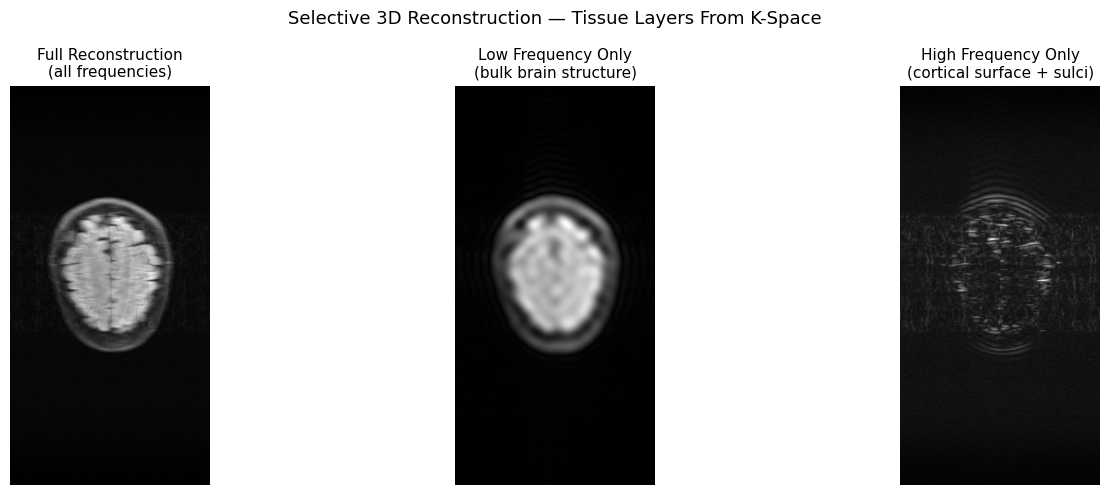

Saved to results/volume_selective_3d.png


In [4]:
print('Building selective frequency volumes...')

low_slices, high_slices = [], []
for i in range(n_slices):
    kspace = load_kspace(H5_FILE, slice_idx=i)
    _, H_k, W_k = kspace.shape
    low_img  = selective_reconstruct(kspace, low_frequency_mask(H_k, W_k, fraction=0.08))
    high_img = selective_reconstruct(kspace, high_frequency_mask(H_k, W_k, fraction=0.08))
    low_slices.append(low_img)
    high_slices.append(high_img)

low_volume  = np.stack(low_slices,  axis=0)
high_volume = np.stack(high_slices, axis=0)

# Compare all three volumes at the same axial slice
mid = D // 2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
imgs   = [volume[mid], low_volume[mid], high_volume[mid]]
titles = [
    'Full Reconstruction\n(all frequencies)',
    'Low Frequency Only\n(bulk brain structure)',
    'High Frequency Only\n(cortical surface + sulci)',
]
for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.suptitle('Selective 3D Reconstruction — Tissue Layers From K-Space', fontsize=13)
plt.tight_layout()
plt.savefig('../results/volume_selective_3d.png', dpi=150)
plt.show()
print('Saved to results/volume_selective_3d.png')

---

## Step 5 — Export as NIfTI for Cornerstone3D

NIfTI (`.nii.gz`) is the standard format for 3D neuroimaging volumes. Cornerstone3D loads NIfTI files directly. Exporting the reconstructed volume as NIfTI means it's immediately viewable in:
- Cornerstone3D (browser-based, used in Meridian)
- 3D Slicer (desktop)
- FSL, Freesurfer, and other neuroimaging tools

Run `pip3 install nibabel` first if not already installed.

In [5]:
try:
    import nibabel as nib

    # Normalize to 0-1 range
    normalized = (volume - volume.min()) / (volume.max() - volume.min())
    normalized = (normalized * 32767).astype(np.int16)

    # Create NIfTI image with identity affine (1mm isotropic voxels)
    affine = np.eye(4)
    nifti_img = nib.Nifti1Image(normalized, affine)

    output_path = '../results/brain_volume.nii.gz'
    nib.save(nifti_img, output_path)
    print(f'Saved NIfTI volume to {output_path}')
    print(f'Volume shape: {normalized.shape}')
    print()
    print('To view in Cornerstone3D:')
    print('  1. Serve the results/ folder with a local HTTP server')
    print('     python3 -m http.server 8080')
    print('  2. Load the NIfTI URL in a Cornerstone3D volume viewport')
    print('     imageId: "nifti:http://localhost:8080/brain_volume.nii.gz"')
    print()
    print('To view in 3D Slicer:')
    print('  File → Add Data → choose brain_volume.nii.gz')

except ImportError:
    print('nibabel not installed. Run: pip3 install nibabel')
    print('Then re-run this cell.')

nibabel not installed. Run: pip3 install nibabel
Then re-run this cell.


---

## What Comes Next — Cornerstone3D Integration

The NIfTI file produced here is the input to Cornerstone3D on the Meridian web platform. The integration looks like this:

```javascript
// In the Meridian ComparisonViewer component:
const imageId = 'nifti:http://your-server/brain_volume.nii.gz';

// Load as a volume viewport
await volumeLoader.loadVolume(imageId);
viewport.setVolumes([{ volumeId: imageId }]);
```

This gives you:
- Full axial/coronal/sagittal navigation
- Volume rendering (3D surface view)
- Annotation pin placement on any plane
- Smart Key Frame screenshots at any coordinate

The pipeline from scanner to interactive 3D viewer is:
```
fastMRI .h5 (raw k-space)
    → Kode RSS reconstruction (this notebook)
    → NIfTI export
    → Cornerstone3D volume renderer
    → Patient sees interactive 3D brain in browser
```

No proprietary software. No DICOM pipeline. No reconstruction black box. The entire path is transparent and controlled.